In [171]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [172]:
fifa = pd.read_csv("fifa21 raw data v2.csv",low_memory=False)

In [189]:
# Percentage of NaNs for each column
total_cells = np.prod(fifa.shape)
total_missing = fifa.isnull().sum()
miss = (total_missing/total_cells) * 100

In [174]:
# Replace all NaNs in Hits with 0
fifa["Hits"] = fifa["Hits"].bfill(axis=0).fillna(0)

In [175]:
# Change Wage from string literal to Number
def wages_num(rows):
    n = len(rows["Wage"])
    last = rows["Wage"][n-1]
    num = 0
    try:
      num = int(float(rows["Wage"][1:n-1]))
    except ValueError:
        num = int(rows["Wage"][1:n])
       
    if last == "K":
        num = num * 1000
    if last == "M":
        num = num * 1000000
        
    rows["Wage"] = num
    return rows["Wage"] 

# Insert a new column for the new Wage numbers
new_wage_col = fifa.apply(wages_num, axis="columns")
fifa.insert(loc=22, column='Wage Number', value=new_wage_col)

In [176]:
# Change Values from string literal to Number
def value_num(rows):
    n = len(rows["Value"])
    last = rows["Value"][n-1]
    num = 0
    try:
      num = int(float(rows["Value"][1:n-1]))
    except ValueError:
        num = int(rows["Value"][1:n])
       
    if last == "K":
        num = num * 1000
    if last == "M":
        num = num * 1000000
        
    rows["Value"] = num
    return rows["Value"] 
# Insert a new column for the new Value numbers    
new_value_col = fifa.apply(value_num, axis="columns")
fifa.insert(loc=21, column='Value Number', value=new_value_col)

In [177]:
# Remove "\n" from the "Club" column
def remove_space(rows):
    return rows["Club"].strip()

fifa["Club"] = fifa.apply(remove_space, axis="columns")

In [178]:
# Remove "*" from the "IR" column
def remove_star(rows):
    x = rows["IR"].replace("★",'')
    return int(x)

fifa["IR"] = fifa.apply(remove_star, axis="columns")

In [179]:
# Rename ↓OVA Column to OVA
fifa.rename(columns={"↓OVA":"OVA"},inplace=True)
# Create a sub DataFrame
sub_fifa = fifa[["ID","Name","Nationality","OVA","Club","Value","Value Number","Wage","Wage Number"]]

In [180]:
# Top 10 rated players
top_rated_players = sub_fifa.sort_values(by="OVA",ascending=False)[:10]
# Highest paid players
highest_paid_players= sub_fifa.sort_values(by="Wage Number",ascending=False)[:20]
# Most Valued players
most_valued_players= sub_fifa.sort_values(by="Value Number",ascending=False)[:20]

In [181]:
# Country with the most players
nation = sub_fifa.groupby("Nationality").Nationality.count().sort_values(ascending=False)
country_most_players = nation.iloc[0]
f_idx = nation.index[0]
print(f"Country: {f_idx}, Players: {country_most_players}")

Country: England, Players: 1705


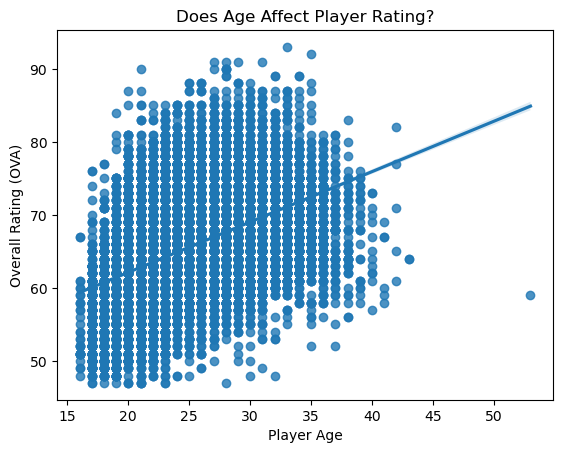

In [188]:
# Does age affect player rating?
#sns.scatterplot(x=fifa["Age"], y=fifa["OVA"])
sns.regplot(x=fifa["Age"], y=fifa["OVA"])
plt.title("Does Age Affect Player Rating?")
plt.xlabel("Player Age")
plt.ylabel("Overall Rating (OVA)")
plt.show()

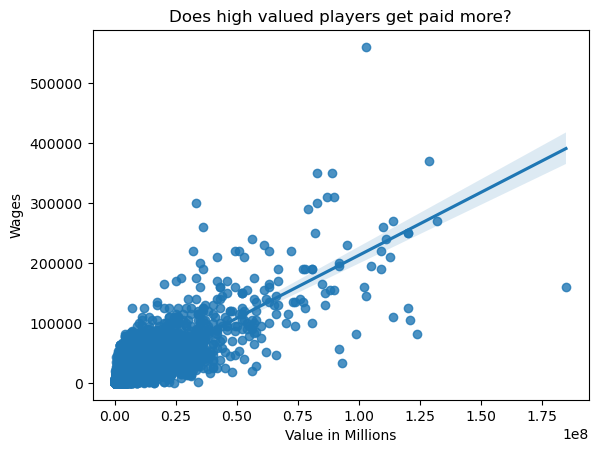

In [195]:
# Does high valued players get paid more?
# Has moderate, positive correlation. Most players that are valued less get paid less. There are a 2 extreme outliers
sns.regplot(x=fifa["Value Number"], y=fifa["Wage Number"])
plt.title("Does high valued players get paid more?")
plt.xlabel("Value in Millions")
plt.ylabel("Wages")
plt.show()